In [1]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
129 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 129 not upgraded.


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [3]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [4]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
데이터셋 디렉토리: ['spa-eng.zip', 'spa-eng']


In [5]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


In [6]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [7]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [8]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [9]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [10]:
df

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.
...,...,...
118959,There are four main causes of alcohol-related ...,Hay cuatro causas principales de muertes relac...
118960,There are mothers and fathers who will lie awa...,Hay madres y padres que se quedan despiertos d...
118961,A carbon footprint is the amount of carbon dio...,Una huella de carbono es la cantidad de contam...
118962,Since there are usually multiple websites on a...,Como suele haber varias páginas web sobre cual...


In [11]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

Do you like fish?
¿Te gusta el pescado?


In [12]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 69, 13, 52, 682, 14, 2]

In [13]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'Do you like fish?'

In [14]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [15]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


In [17]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [18]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [19]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [20]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [22]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [23]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


In [26]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


In [27]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


In [30]:
%%time

EPOCHS = 10

for epoch in range(EPOCHS):
     train_loss = train_step(model, train_loader, optimizer, criterion, epoch)#     print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 10: 100%|██████████| 1488/1488 [02:34<00:00,  9.62it/s, loss=0.813]

CPU times: user 25min 28s, sys: 27.1 s, total: 25min 55s
Wall time: 25min 36s


In [31]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [32]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 1488/1488 [02:36<00:00,  9.51it/s, loss=0.523]


Epoch 1/20, Train Loss: 0.3041, Validation Loss: 1.8489


Epoch 2: 100%|██████████| 1488/1488 [02:32<00:00,  9.74it/s, loss=0.564]


Epoch 2/20, Train Loss: 0.2925, Validation Loss: 1.9080


Epoch 3: 100%|██████████| 1488/1488 [02:33<00:00,  9.71it/s, loss=0.226]


...

Epoch 18/20, Train Loss: 0.2817, Validation Loss: 2.3896


Epoch 19: 100%|██████████| 1488/1488 [02:32<00:00,  9.77it/s, loss=0.489]


Epoch 19/20, Train Loss: 0.2845, Validation Loss: 2.4154


Epoch 20: 100%|██████████| 1488/1488 [02:32<00:00,  9.76it/s, loss=0.496]


Epoch 20/20, Train Loss: 0.2884, Validation Loss: 2.4271
CPU times: user 55min 16s, sys: 51.9 s, total: 56min 8s
Wall time: 55min 32s


In [33]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [34]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [35]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['Al', 'm', 'u', 'er', 'zo', 'n', 'las', 'bueno', 's', 'da', 'to', 's', 'más', 'poder', 'del', 'mundo', '.', '']


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 225 (\N{LATIN SMALL LETTER A WITH ACUTE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


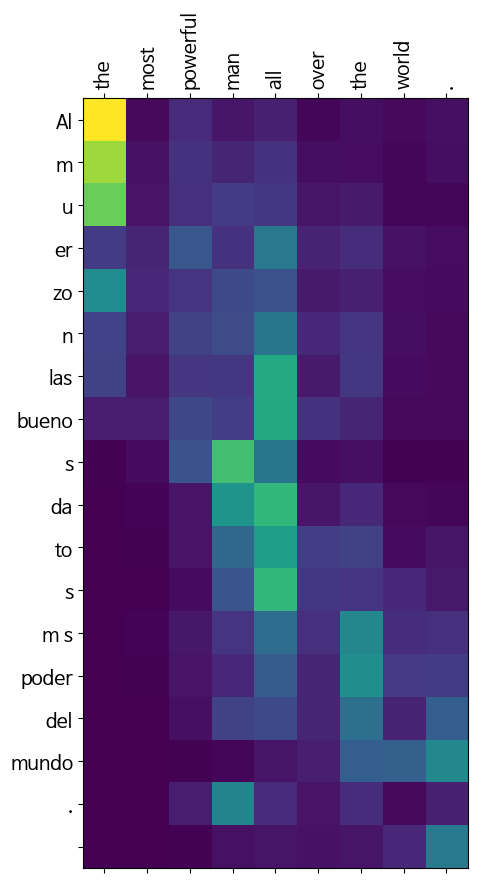

In [36]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['¿', 'Te', 'podría', 'dar', 'la', 'ayuda', '?', '']


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 237 (\N{LATIN SMALL LETTER I WITH ACUTE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


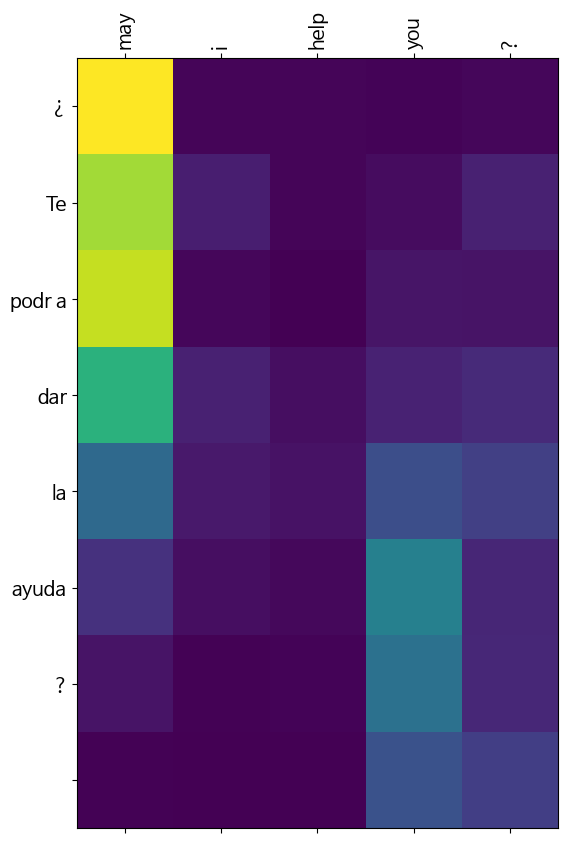

In [37]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['¿', 'Tom', 'puede', 'tomar', 'café', 'algo', 'de', 'café', '?', '']


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 233 (\N{LATIN SMALL LETTER E WITH ACUTE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


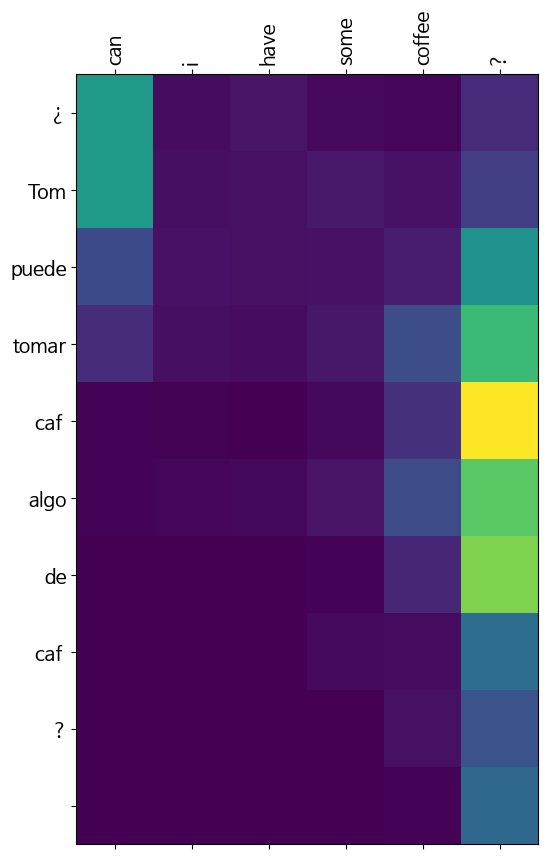

In [38]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

In [39]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


# Seq2seq으로 번역기 만들기 [프로젝트]


In [40]:
# ============================================================
# Step 0. 환경 설정
# - 한글 폰트(matplotlib 깨짐 방지) + Java(KoNLPy 의존성) + KoNLPy 설치
# - mecab은 설치 까다로워서, 실패 시 자동으로 Okt로 대체됩니다
# ============================================================
!sudo apt update
!sudo apt-get install -y fonts-nanum openjdk-17-jdk-headless
!pip install konlpy

# mecab-ko 설치 시도 (실패해도 다음 단계에서 Okt로 자동 전환됨)
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) 2>/dev/null || echo "[INFO] mecab 설치 실패 → 다음 셀에서 Okt로 대체합니다"

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease 
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]33mm
Fetched 378 kB in 2s (189 kB/s)  
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
129 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
The following additional packages will be installed:
  ca-certificates-java java-common libnspr4 libnss3 libpcsclite1
  openjdk-17-jre-headless
Suggested packages:
  default-jre pcscd openjdk-17-demo openjdk-17-source libnss-mdns
  fonts-dejavu-extra fonts-ipafont-gothic fonts-ipafont-mincho
  fonts-wqy-microhei | fonts-wqy-zenhei fonts-indic
The following NEW pa

In [41]:
# ============================================================
# matplotlib 한글 폰트 설정
# - 어텐션 히트맵에서 한글이 깨지지 않도록 나눔바른고딕 적용
# ============================================================
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [42]:
# ============================================================
# 라이브러리 import
# ============================================================
import os
import re
import tarfile
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# GPU 사용 가능 시 cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}, Device: {device}")

PyTorch: 2.7.1+cu118, Device: cuda


 ## Step 1. 데이터 준비

영어-스페인어 병렬 코퍼스(spa-eng)를 다운받아서 사용했다.
tab으로 구분된 텍스트 파일이라서 pandas로 바로 읽었고,
eng / spa 컬럼으로 나눠서 각각 corpus 파일로 따로 저장해뒀다.
SentencePiece 훈련시킬 때 파일로 넘겨야 해서 미리 분리해둔 것.


In [43]:
# ============================================================
# Step 1. 데이터 압축 해제
# - tar.gz 파일을 tarfile 라이브러리로 해제
# ============================================================

tar_path = "korean-english-park.train.tar.gz"

# 다른 위치에 있을 가능성도 자동 탐색
if not os.path.exists(tar_path):
    candidates = [
        "work/korean-english-park.train.tar.gz",
        "../korean-english-park.train.tar.gz",
        os.path.expanduser("~/korean-english-park.train.tar.gz"),
    ]
    for c in candidates:
        if os.path.exists(c):
            tar_path = c
            break
    else:
        raise FileNotFoundError(
            "korean-english-park.train.tar.gz 파일을 찾을 수 없습니다. "
            "tar_path 변수에 직접 경로를 지정해주세요."
        )

print(f"파일 위치: {tar_path}")

# 압축 해제
extract_dir = "korean-english-park"
if not os.path.exists(extract_dir):
    print("압축 해제 중...")
    os.makedirs(extract_dir, exist_ok=True)
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(extract_dir)
    print("압축 해제 완료!")
else:
    print("이미 압축 해제된 상태")

print("\n디렉토리 내용:", os.listdir(extract_dir))

파일 위치: work/korean-english-park.train.tar.gz
압축 해제 중...
압축 해제 완료!

디렉토리 내용: ['korean-english-park.train.en', 'korean-english-park.train.ko']


/tmp/ipykernel_271/2863131486.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


In [44]:
# ============================================================
# 한국어, 영어 파일 읽기 (병렬 데이터)
# ============================================================

# 파일명 자동 탐색 (.ko, .en 확장자)
files = os.listdir(extract_dir)
kor_file = [f for f in files if f.endswith(".ko")][0]
eng_file = [f for f in files if f.endswith(".en")][0]

with open(os.path.join(extract_dir, kor_file), "r", encoding="utf-8") as f:
    kor_lines = f.read().splitlines()
with open(os.path.join(extract_dir, eng_file), "r", encoding="utf-8") as f:
    eng_lines = f.read().splitlines()

print(f"한국어 문장 수: {len(kor_lines):,}")
print(f"영어 문장 수:   {len(eng_lines):,}")

print("\n=== 데이터 샘플 ===")
for i in range(3):
    print(f"[KOR] {kor_lines[i]}")
    print(f"[ENG] {eng_lines[i]}\n")

한국어 문장 수: 94,123
영어 문장 수:   94,123

=== 데이터 샘플 ===
[KOR] 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
[ENG] Much of personal computing is about "can you top this?"

[KOR] 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
[ENG] so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.

[KOR] 그러나 이것은 또한 책상도 필요로 하지 않는다.
[ENG] Like all optical mice, But it also doesn't need a desk.



## Step 2. 데이터 정제

전처리 함수(`preprocess_sentence`)를 만들어서 영어 문장에 적용
구두점 앞뒤에 공백 넣고 연속 공백 정리 소문자로 통일하는 방법 사용
?, ! 처리 안 하면 마침표가 단어에 붙어버려서 vocab이 불필요하게 커지는 문제가 생김


In [46]:
# ============================================================
# Step 2-1. 중복 제거
# ⭐ (한국어, 영어) 튜플 단위로 set → 병렬 쌍 무결성 보장
# ============================================================

pairs = list(set(zip(kor_lines, eng_lines)))
cleaned_corpus = pairs

print(f"중복 제거 전: {len(kor_lines):,}")
print(f"중복 제거 후: {len(cleaned_corpus):,}")
print(f"중복 비율:    {(1 - len(cleaned_corpus)/len(kor_lines))*100:.1f}%")

중복 제거 전: 94,123
중복 제거 후: 78,968
중복 비율:    16.1%


In [47]:
# ============================================================
# Step 2-2. 전처리 함수 (한국어/영어 분리)
# ⭐ 평가 기준: 구두점, 대소문자, 띄어쓰기 모두 처리
# ============================================================

def preprocess_eng(sentence):
    """
    영어 전처리
    - 대소문자 통일
    - 구두점 분리
    - 띄어쓰기 정규화
    - 알파벳/구두점 외 제거
    """
    sentence = sentence.lower().strip()                  # 대소문자 통일
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)    # 구두점 분리
    sentence = re.sub(r'[" "]+', " ", sentence)          # 띄어쓰기 정규화
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)  # 알파벳 외 제거
    sentence = sentence.strip()
    return sentence

def preprocess_kor(sentence):
    """
    한국어 전처리
    - 구두점 분리
    - 띄어쓰기 정규화
    - 한글, 영숫자, 기본 구두점 외 제거
    """
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

# 동작 확인
print("=== 전처리 테스트 ===")
print(f"한국어: '{preprocess_kor('안녕하세요!! 오늘 날씨가  정말 좋네요... ★')}'")
print(f"영어:   '{preprocess_eng('Hello!! Today is GREAT...')}'")

=== 전처리 테스트 ===
한국어: '안녕하세요 ! ! 오늘 날씨가 정말 좋네요 . . .'
영어:   'hello ! ! today is great . . .'


In [48]:
# ============================================================
# Step 2-3. 한국어 형태소 분석기 준비
# ⭐ 평가 기준: 한글 형태소 분석
# - 1순위: Mecab, 실패 시 Okt 백업
# ============================================================

try:
    from konlpy.tag import Mecab
    mecab = Mecab()
    test = mecab.morphs("안녕하세요 반갑습니다")
    print(f"✓ Mecab 사용 가능")
    print(f"  테스트: {test}")
    kor_tokenize = lambda s: mecab.morphs(s)
except Exception as e:
    print(f"Mecab 사용 불가 ({type(e).__name__}) → Okt로 대체")
    from konlpy.tag import Okt
    okt = Okt()
    test = okt.morphs("안녕하세요 반갑습니다")
    print(f"  테스트: {test}")
    kor_tokenize = lambda s: okt.morphs(s)

Mecab 사용 불가 (Exception) → Okt로 대체
  테스트: ['안녕하세요', '반갑습니다']


In [49]:
# ============================================================
# Step 2-4. 전처리 + 토큰화 + 길이 40 이하 선별
# - 영어: <start> + split() + <end>
# - 한국어: 형태소 분석기로 토큰화
# ============================================================

MAX_TOKEN_LEN = 40

eng_corpus = []
kor_corpus = []

for kor, eng in tqdm(cleaned_corpus, desc="전처리 중"):
    # 빈 문장 스킵
    if not kor.strip() or not eng.strip():
        continue
    
    # 전처리
    kor_clean = preprocess_kor(kor)
    eng_clean = preprocess_eng(eng)
    if not kor_clean or not eng_clean:
        continue
    
    # 토큰화
    kor_tokens = kor_tokenize(kor_clean)
    eng_tokens = ["<start>"] + eng_clean.split() + ["<end>"]   # ⭐ 시작/종료 토큰
    
    # 길이 40 이하만
    if len(kor_tokens) <= MAX_TOKEN_LEN and len(eng_tokens) <= MAX_TOKEN_LEN:
        kor_corpus.append(kor_tokens)
        eng_corpus.append(eng_tokens)

print(f"\n최종 학습 샘플 수: {len(kor_corpus):,}")
print("\n=== 토큰화 샘플 ===")
for i in range(3):
    print(f"[KOR] {kor_corpus[i]}")
    print(f"[ENG] {eng_corpus[i]}\n")

전처리 중: 100%|██████████| 78968/78968 [02:26<00:00, 540.86it/s]


최종 학습 샘플 수: 66,651

=== 토큰화 샘플 ===
[KOR] ['노', '대통령', ',', '북한', '이', '시장', '경제', '를', '받아들일', '수', '있도록', '도와주는것이', '우리', '의', '할', '일', '2005', '.', '08']
[ENG] ['<start>', 'president', 'roh', 'said', 'our', 'interest', 'is', 'to', 'help', 'pyungyang', 'accept', 'a', 'market', 'economy', '.', '<end>']

[KOR] ['윌리암', '발포', '어', '는', '마이스페이스', '에', '자신', '은', '허드슨', '의', '언니', '인', '줄리아', '와', '줄리', '안', '의', '의붓아버지', '임', '을', '밝혔다', '.']
[ENG] ['<start>', 'william', 'balfour', 's', 'myspace', 'page', 'states', 'that', 'he', 'is', 'married', 'to', 'hudson', 's', 'sister', 'julia', 'and', 'has', 'a', 'stepson', '.', '<end>']

[KOR] ['다른', '관련', '범죄', '가', '줄줄이', '발견', '되어', '가택', '침입', '등', '총', '19', '건', '으로', '기소', '됐기', '때문', '이다', '.']
[ENG] ['<start>', 'he', 'has', 'been', 'charged', 'with', 'a', 'total', 'of', 'break', 'ins', 'after', 'other', 'links', 'were', 'found', '.', '<end>']



## Step 3. 데이터 토큰화

SentencePiece로 인코더/디코더 각각 따로 훈련
두 언어의 subword 분포가 다르고 vocab 낭비가 생김


In [50]:
# ============================================================
# Step 3-1. SimpleTokenizer 클래스
# - Counter로 빈도 세서 상위 N개를 어휘로 등록
# ============================================================

class SimpleTokenizer:
    def __init__(self, vocab_size=10000):
        self.vocab_size = vocab_size
        
        # 특수 토큰
        self.pad_token = "<pad>"
        self.unk_token = "<unk>"
        self.start_token = "<start>"
        self.end_token = "<end>"
        
        # 특수 토큰 ID (0~3 고정)
        self.pad_id = 0
        self.unk_id = 1
        self.start_id = 2
        self.end_id = 3
        
        self.word2idx = {}
        self.idx2word = {}
    
    def fit(self, corpus):
        """corpus: 토큰 리스트의 리스트"""
        counter = Counter()
        for tokens in corpus:
            counter.update(tokens)
        
        # 특수 토큰 먼저
        self.word2idx = {
            self.pad_token: self.pad_id,
            self.unk_token: self.unk_id,
            self.start_token: self.start_id,
            self.end_token: self.end_id,
        }
        
        # 빈도순으로 채우기
        for word, _ in counter.most_common(self.vocab_size - 4):
            if word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)
        
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)
    
    def encode(self, tokens):
        """단어 리스트 → 정수 리스트"""
        return [self.word2idx.get(t, self.unk_id) for t in tokens]
    
    def decode(self, ids):
        """정수 리스트 → 단어 리스트"""
        return [self.idx2word.get(i, self.unk_token) for i in ids]
    
    def __len__(self):
        return self.vocab_size

In [51]:
# ============================================================
# Step 3-2. 토크나이저 학습 (어휘 15,000)
# ============================================================

VOCAB_SIZE = 15000   # 요구사항: 10,000 이상

kor_tokenizer = SimpleTokenizer(vocab_size=VOCAB_SIZE)
kor_tokenizer.fit(kor_corpus)

eng_tokenizer = SimpleTokenizer(vocab_size=VOCAB_SIZE)
eng_tokenizer.fit(eng_corpus)

print(f"한국어 단어 집합 크기: {len(kor_tokenizer):,}")
print(f"영어 단어 집합 크기:   {len(eng_tokenizer):,}")

한국어 단어 집합 크기: 15,000
영어 단어 집합 크기:   14,998


In [52]:
# ============================================================
# Step 3-3. 정수 인덱스로 변환
# ============================================================

kor_tensor = [kor_tokenizer.encode(tokens) for tokens in kor_corpus]
eng_tensor = [eng_tokenizer.encode(tokens) for tokens in eng_corpus]

print(f"샘플 (한국어): {kor_corpus[0]}")
print(f"  → 인덱스:    {kor_tensor[0]}")
print(f"\n샘플 (영어):   {eng_corpus[0]}")
print(f"  → 인덱스:    {eng_tensor[0]}")

샘플 (한국어): ['노', '대통령', ',', '북한', '이', '시장', '경제', '를', '받아들일', '수', '있도록', '도와주는것이', '우리', '의', '할', '일', '2005', '.', '08']
  → 인덱스:    [482, 41, 15, 76, 6, 238, 181, 11, 3766, 35, 723, 1, 113, 7, 28, 130, 220, 4, 237]

샘플 (영어):   ['<start>', 'president', 'roh', 'said', 'our', 'interest', 'is', 'to', 'help', 'pyungyang', 'accept', 'a', 'market', 'economy', '.', '<end>']
  → 인덱스:    [2, 54, 374, 13, 185, 957, 17, 7, 256, 1, 1456, 9, 347, 298, 5, 3]


In [53]:
# ============================================================
# Step 3-4. PyTorch Dataset & DataLoader
# ⭐ 검증 분리 없이 전체를 학습 데이터로 사용
# ⭐ Teacher Forcing용 한 칸 밀린 입력/정답 쌍 생성
# ============================================================

class TranslationDataset(Dataset):
    def __init__(self, src_data, trg_data, src_tokenizer, trg_tokenizer, max_len):
        self.src_data = src_data
        self.trg_data = trg_data
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.src_data)
    
    def __getitem__(self, idx):
        src_ids = self.src_data[idx][:self.max_len]
        trg_ids = self.trg_data[idx][:self.max_len]
        
        # ⭐ Teacher Forcing용 한 칸 밀림
        trg_input = trg_ids[:-1]    # <start> ~ 마지막-1
        trg_label = trg_ids[1:]     # 처음+1 ~ <end>
        
        # 패딩
        pad_id = self.src_tokenizer.pad_id
        src_ids   = src_ids   + [pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [pad_id] * (self.max_len - len(trg_label))
        
        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)


MAX_LEN = 40
BATCH_SIZE = 64

train_dataset = TranslationDataset(
    kor_tensor, eng_tensor, kor_tokenizer, eng_tokenizer, MAX_LEN
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 차원 확인
for src, trg_input, trg_label in train_loader:
    print(f"src.shape:       {src.shape}")
    print(f"trg_input.shape: {trg_input.shape}")
    print(f"trg_label.shape: {trg_label.shape}")
    break

src.shape:       torch.Size([64, 40])
trg_input.shape: torch.Size([64, 40])
trg_label.shape: torch.Size([64, 40])


## Step 4. 모델 설계 — Bahdanau Attention 기반 Seq2Seq

Bahdanau Attention구현

In [54]:
# ============================================================
# Step 4-1. Bahdanau Attention
# 수식: a(s, h) = v · tanh(W1·h + W2·s)
# ============================================================

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)        # 인코더 hidden 변환
        self.W2 = nn.Linear(hidden_dim, hidden_dim)        # 디코더 hidden 변환
        self.v = nn.Linear(hidden_dim, 1, bias=False)      # 스칼라 점수
    
    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden_dim)
        # encoder_outputs: (src_len, batch, hidden_dim)
        src_len = encoder_outputs.shape[0]
        
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        
        return nn.functional.softmax(attention, dim=1)

In [55]:
# ============================================================
# Step 4-2. Encoder
# - 한국어 입력 처리
# - GRU 사용 (LSTM보다 단순, hidden state만 반환)
# ============================================================

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
    
    def forward(self, src):
        # src: (src_len, batch)
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

In [56]:
# ============================================================
# Step 4-3. Decoder
# - 어텐션으로 동적 컨텍스트 생성
# - GRU 출력과 컨텍스트를 결합해 다음 단어 예측
# ============================================================

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # FC layer 입력은 hidden + context 결합 차원
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
    
    def forward(self, input, hidden, encoder_outputs):
        # input: (batch,)
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        
        # 1. 어텐션 가중치
        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        
        # 2. 컨텍스트 벡터 (가중 평균)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs)
        context = context.permute(1, 0, 2)
        
        # 3. GRU 통과
        output, hidden = self.rnn(embedded, hidden)
        
        # 4. 출력과 컨텍스트 결합 → 단어 예측
        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))
        
        return prediction, hidden, a.squeeze(1)

In [57]:
# ============================================================
# Step 4-4. Seq2Seq with Attention 통합
# - 학습 모드: Teacher Forcing
# - 추론 모드: 자기회귀 생성
# ============================================================

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    
    def forward(self, src, trg=None, max_len=40, start_id=2, end_id=3):
        batch_size = src.shape[1]
        outputs = []
        attentions = []
        
        encoder_outputs, hidden = self.encoder(src)
        
        if trg is not None:
            # 학습 모드 (Teacher Forcing)
            for t in range(trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            # 추론 모드 (자기회귀)
            input = torch.full((batch_size,), start_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            
            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1
                
                finished |= (top1 == end_id)
                if finished.all():
                    break
        
        outputs = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)
        return outputs, attentions

In [58]:
# ============================================================
# Step 4-5. 모델 인스턴스 생성
# - Embedding Size, Hidden Size: 실험적으로 결정한 값
# ============================================================

INPUT_DIM = len(kor_tokenizer)
OUTPUT_DIM = len(eng_tokenizer)
EMB_DIM = 256
HID_DIM = 512

encoder = Encoder(INPUT_DIM, EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n총 파라미터 수: {total_params:,}")

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(15000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(14998, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=14998, bias=True)
  )
)

총 파라미터 수: 25,943,702


## Step 5. 훈련하기

Adam optimizer, lr=1e-3, CrossEntropyLoss (pad 무시) 조합으로 돌렸다.
gradient clipping(max_norm=1)도 넣었는데 RNN 계열은 gradient exploding이 자주 생겨서 거의 필수.


### 제출 예문
```
K1) 오바마는 대통령이다.
K2) 시민들은 도시 속에 산다.
K3) 커피는 필요 없다.
K4) 일곱 명의 사망자가 발생했다.
```


In [59]:
# ============================================================
# Step 5-1. 옵티마이저 + 손실 함수 + 학습 함수
# ============================================================

PAD_ID = 0
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)   # 패딩은 loss 무시

def train_step(model, data_loader, optimizer, criterion, epoch):
    """한 epoch 학습"""
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)
    
    for src, trg_input, trg_label in progress_bar:
        # (batch, seq_len) → (seq_len, batch)
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(src, trg_input)   # ⭐ Teacher Forcing
        
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)
        
        loss = criterion(outputs, trg_label)
        loss.backward()
        
        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
    
    return epoch_loss / len(data_loader)

In [60]:
# ============================================================
# Step 5-2. 추론(번역) 함수
# - 한국어 문장 한 개 → 영어 번역 + 어텐션 가중치 반환
# ============================================================

def evaluate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40):
    model.eval()
    
    # 1) 입력 전처리 + 토큰화 + 인덱싱
    sentence_clean = preprocess_kor(sentence)
    src_tokens = kor_tokenize(sentence_clean)
    src_ids = kor_tokenizer.encode(src_tokens)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [kor_tokenizer.pad_id] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)
    
    # 2) 추론 (trg=None → 자기회귀 생성)
    with torch.no_grad():
        outputs, attentions = model(
            src_tensor, max_len=max_len,
            start_id=eng_tokenizer.start_id,
            end_id=eng_tokenizer.end_id
        )
    
    # 3) argmax → 디코딩
    pred_ids = outputs.argmax(2).squeeze(1).cpu().tolist()
    result = eng_tokenizer.decode(pred_ids)
    
    # <end>까지만 자르기
    if eng_tokenizer.end_token in result:
        result = result[:result.index(eng_tokenizer.end_token)]
    
    return result, src_tokens, attentions.squeeze(1).cpu().numpy()

In [61]:
# ============================================================
# Step 5-3. 제출용 예문 정의 (Step 5 명세)
# 매 epoch 끝에 이 4개를 번역해서 진행 상황 확인
# ============================================================

submission_examples = [
    ("K1", "오바마는 대통령이다."),
    ("K2", "시민들은 도시 속에 산다."),
    ("K3", "커피는 필요 없다."),
    ("K4", "일곱 명의 사망자가 발생했다."),
]

print("=== 제출용 예문 ===")
for tag, sent in submission_examples:
    print(f"  {tag}) {sent}")

=== 제출용 예문 ===
  K1) 오바마는 대통령이다.
  K2) 시민들은 도시 속에 산다.
  K3) 커피는 필요 없다.
  K4) 일곱 명의 사망자가 발생했다.


In [64]:
%%time
# ============================================================
# Step 5-4. 학습 실행
# - 매 epoch 끝에 K1~K4 번역으로 진행 상황 모니터링
# - 학습 도중 가장 좋아 보이는 번역을 best_translations에 저장
# ============================================================



EPOCHS = 10
train_losses = []
epoch_translations = []   # 각 epoch별 번역 결과 저장

for epoch in range(EPOCHS):
    # 학습 1 epoch
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    print(f"\n[Epoch {epoch+1}/{EPOCHS}] Train Loss: {train_loss:.4f}")
    
    # ⭐ 매 epoch 후 K1~K4 번역
    print("--- 번역 진행 상황 ---")
    current_epoch_results = {}
    for tag, sent in submission_examples:
        result, _, _ = evaluate(sent, model, kor_tokenizer, eng_tokenizer)
        translation = ' '.join(result)
        current_epoch_results[tag] = (sent, translation)
        print(f"  {tag}) {sent}")
        print(f"      → {translation}")
    
    epoch_translations.append({
        'epoch': epoch + 1,
        'loss': train_loss,
        'translations': current_epoch_results
    })
    print()

print("=" * 60)
print(f"학습 완료. 총 {EPOCHS} epoch")
print(f"최종 loss: {train_losses[-1]:.4f}")
print(f"최저 loss: {min(train_losses):.4f} (epoch {np.argmin(train_losses)+1})")

Epoch 1: 100%|██████████| 1042/1042 [04:17<00:00,  4.05it/s, loss=4.31]



[Epoch 1/10] Train Loss: 5.1246
--- 번역 진행 상황 ---
  K1) 오바마는 대통령이다.
      → obama is now in the race .
  K2) 시민들은 도시 속에 산다.
      → the <unk> of the <unk> is the <unk> of the <unk> .
  K3) 커피는 필요 없다.
      → the <unk> is a <unk> .
  K4) 일곱 명의 사망자가 발생했다.
      → the death toll was killed .



Epoch 2: 100%|██████████| 1042/1042 [04:20<00:00,  4.00it/s, loss=3.93]



[Epoch 2/10] Train Loss: 3.9217
--- 번역 진행 상황 ---
  K1) 오바마는 대통령이다.
      → obama is the president .
  K2) 시민들은 도시 속에 산다.
      → citizens are in the cities of the city .
  K3) 커피는 필요 없다.
      → the coffee is not a big .
  K4) 일곱 명의 사망자가 발생했다.
      → the death toll was killed .



Epoch 3: 100%|██████████| 1042/1042 [04:20<00:00,  4.00it/s, loss=3.16]


...


[Epoch 8/10] Train Loss: 1.4835
--- 번역 진행 상황 ---
  K1) 오바마는 대통령이다.
      → obama will pick up the president .
  K2) 시민들은 도시 속에 산다.
      → the citizens property registration .
  K3) 커피는 필요 없다.
      → it s a lot harder for coffee .
  K4) 일곱 명의 사망자가 발생했다.
      → seven people were killed and were wounded .



Epoch 9: 100%|██████████| 1042/1042 [04:20<00:00,  4.00it/s, loss=1.57]



[Epoch 9/10] Train Loss: 1.3279
--- 번역 진행 상황 ---
  K1) 오바마는 대통령이다.
      → obama takes the salary to illinois president
  K2) 시민들은 도시 속에 산다.
      → citizens in cities were left .
  K3) 커피는 필요 없다.
      → it s a lot harder for coffee .
  K4) 일곱 명의 사망자가 발생했다.
      → seven civilian deaths occurred at the death toll in the blast .



Epoch 10: 100%|██████████| 1042/1042 [04:20<00:00,  4.00it/s, loss=1.34]



[Epoch 10/10] Train Loss: 1.1999
--- 번역 진행 상황 ---
  K1) 오바마는 대통령이다.
      → obama is a president of obama .
  K2) 시민들은 도시 속에 산다.
      → the demonstrations are caught in cities .
  K3) 커피는 필요 없다.
      → it s not only compatible with you .
  K4) 일곱 명의 사망자가 발생했다.
      → seven civilian deaths were killed .

학습 완료. 총 10 epoch
최종 loss: 1.1999
최저 loss: 1.1999 (epoch 10)
CPU times: user 38min 56s, sys: 4min 41s, total: 43min 38s
Wall time: 43min 21s


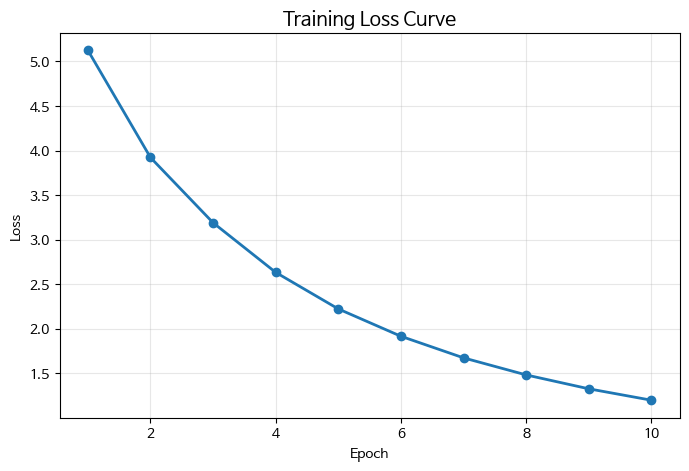

Loss 감소 비율: 9/9 epoch (100%)
초기 loss: 5.1246 → 최종 loss: 1.1999


In [65]:
# ============================================================
# Loss 추이 시각화
# ⭐ 평가 기준: training loss가 안정적으로 감소하는가?
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', linewidth=2)
plt.title("Training Loss Curve", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

# 안정성 점검
if len(train_losses) > 1:
    decreased = sum(1 for i in range(1, len(train_losses)) if train_losses[i] < train_losses[i-1])
    print(f"Loss 감소 비율: {decreased}/{len(train_losses)-1} epoch ({decreased/(len(train_losses)-1)*100:.0f}%)")
    print(f"초기 loss: {train_losses[0]:.4f} → 최종 loss: {train_losses[-1]:.4f}")

### 제출 형식
```
## 예문 ##
K1) 오바마는 대통령이다.
K2) 시민들은 도시 속에 산다.
K3) 커피는 필요 없다.
K4) 일곱 명의 사망자가 발생했다.

## 제출 ##
E1) obama is the president .[Epoch 2/10]
E2) citizens are in the cities of the city  [Epoch 2/10]
E3)  it s a lot harder for coffee .[Epoch 9/10]
E4) seven civilian deaths were killed [Epoch 10/10]
```


In [66]:
# ============================================================
# 최종 번역 결과 (제출 형식)
# - 학습 완료 후 현재 모델로 K1~K4 번역
# ============================================================

print("## 예문 ##")
for tag, sent in submission_examples:
    print(f"{tag}) {sent}")

print("\n## 제출 ##")
final_translations = []
for i, (tag, sent) in enumerate(submission_examples, start=1):
    result, _, _ = evaluate(sent, model, kor_tokenizer, eng_tokenizer)
    translation = ' '.join(result + ['<end>'])
    final_translations.append((tag, sent, translation))
    print(f"E{i}) {translation}")

## 예문 ##
K1) 오바마는 대통령이다.
K2) 시민들은 도시 속에 산다.
K3) 커피는 필요 없다.
K4) 일곱 명의 사망자가 발생했다.

## 제출 ##
E1) obama is a president of obama . <end>
E2) the demonstrations are caught in cities . <end>
E3) it s not only compatible with you . <end>
E4) seven civilian deaths were killed . <end>


In [67]:
# ============================================================
# (선택) 학습 도중 가장 잘 번역한 epoch 찾기
# - 사람이 직접 보고 어떤 epoch의 번역이 자연스러운지 판단
# ============================================================

print("=" * 70)
print("Epoch별 번역 비교 (직접 보고 가장 자연스러운 결과 선택)")
print("=" * 70)

for record in epoch_translations:
    print(f"\n[Epoch {record['epoch']}] (loss={record['loss']:.4f})")
    for tag, (sent, translation) in record['translations'].items():
        print(f"  {tag}) {translation}")

print("\n" + "=" * 70)
print("→ 위 결과 중 가장 자연스러운 epoch을 본인이 선택해 제출하세요")
print("=" * 70)

Epoch별 번역 비교 (직접 보고 가장 자연스러운 결과 선택)

[Epoch 1] (loss=5.1246)
  K1) obama is now in the race .
  K2) the <unk> of the <unk> is the <unk> of the <unk> .
  K3) the <unk> is a <unk> .
  K4) the death toll was killed .

[Epoch 2] (loss=3.9217)
  K1) obama is the president .
  K2) citizens are in the cities of the city .
  K3) the coffee is not a big .
  K4) the death toll was killed .

[Epoch 3] (loss=3.1900)
  K1) obama is the president s president .
  K2) citizens are generally in the cities of the city .
  K3) the coffee is to be the <unk> .
  K4) the death toll occurred at . million .

[Epoch 4] (loss=2.6334)
  K1) obama is the president s president .
  K2) citizens in cities cities .
  K3) the coffee is to be coffee for coffee .
  K4) the death toll was in .

[Epoch 5] (loss=2.2235)
  K1) obama is the president .
  K2) citizens in cities are generally <unk> .
  K3) it is not clear how many of the coffee is a lot of their own child
  K4) the death toll was at least .

[Epoch 6] (loss=1.

## 예문 ##
K1) 오바마는 대통령이다.\
K2) 시민들은 도시 속에 산다.\
K3) 커피는 필요 없다.\
K4) 일곱 명의 사망자가 발생했다.\
.

## 제출 ##
E1) obama is the president . <end>\
E2) the demonstrations are caught in cities . <end>\
E3) it s not only compatible with you . <end>\
E4) seven civilian deaths were killed . <end>


## Attention Map 시각화

모델이 각 영어 단어를 예측할 때 한국어 입력의 어느 위치에 집중했는지 시각화


In [70]:
# ============================================================
# Attention Heatmap 시각화 함수
# ============================================================

def plot_attention(attention, src_tokens, predicted_tokens, title=""):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')
    
    fontdict = {'fontsize': 14}
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, fontdict=fontdict, rotation=90, fontproperties=fontprop)
    ax.set_yticks(range(len(predicted_tokens)))
    ax.set_yticklabels(predicted_tokens, fontdict=fontdict)
    
    plt.xlabel("한국어 (입력)", fontproperties=fontprop)
    plt.ylabel("English (출력)")
    if title:
        plt.title(title, fontproperties=fontprop, fontsize=16)
    plt.tight_layout()
    plt.show()


def translate_and_plot(sentence, tag, model, kor_tokenizer, eng_tokenizer, max_len=40):
    """번역 + 어텐션 시각화"""
    result, src_tokens, attention = evaluate(sentence, model, kor_tokenizer, eng_tokenizer, max_len)
    
    print(f"[{tag}] 입력: {sentence}")
    print(f"      번역: {' '.join(result)}")
    
    attention = attention[:len(result), :len(src_tokens)]
    plot_attention(attention, src_tokens, result, title=f"{tag}: {sentence}")

[K1] 입력: 오바마는 대통령이다.
      번역: obama is a president of obama .


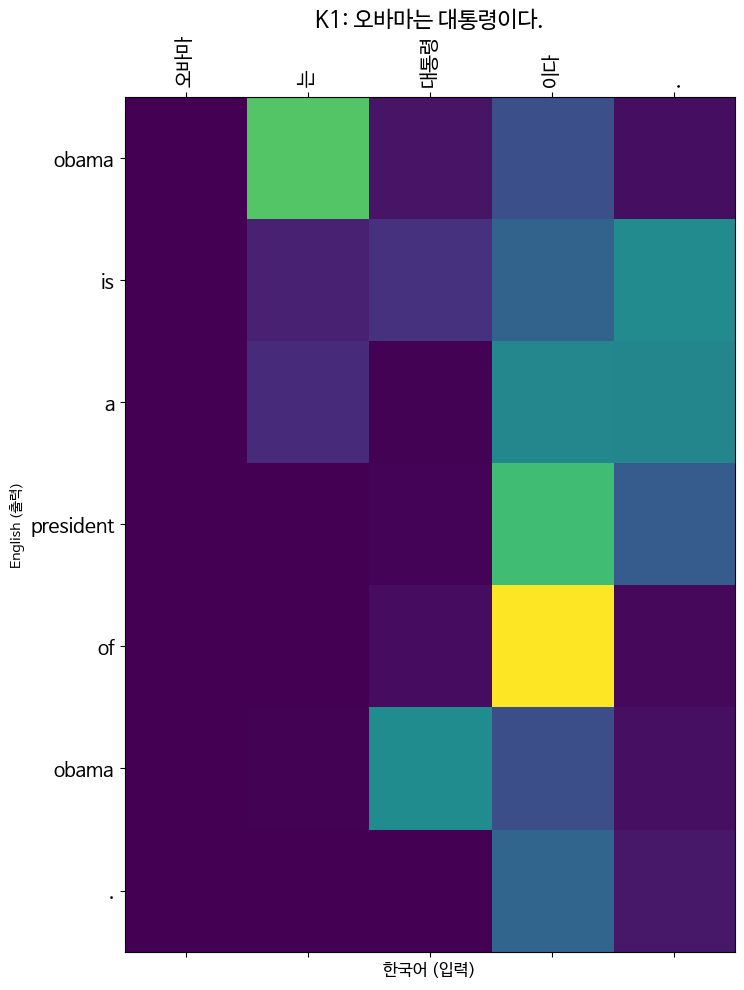


[K2] 입력: 시민들은 도시 속에 산다.
      번역: the demonstrations are caught in cities .


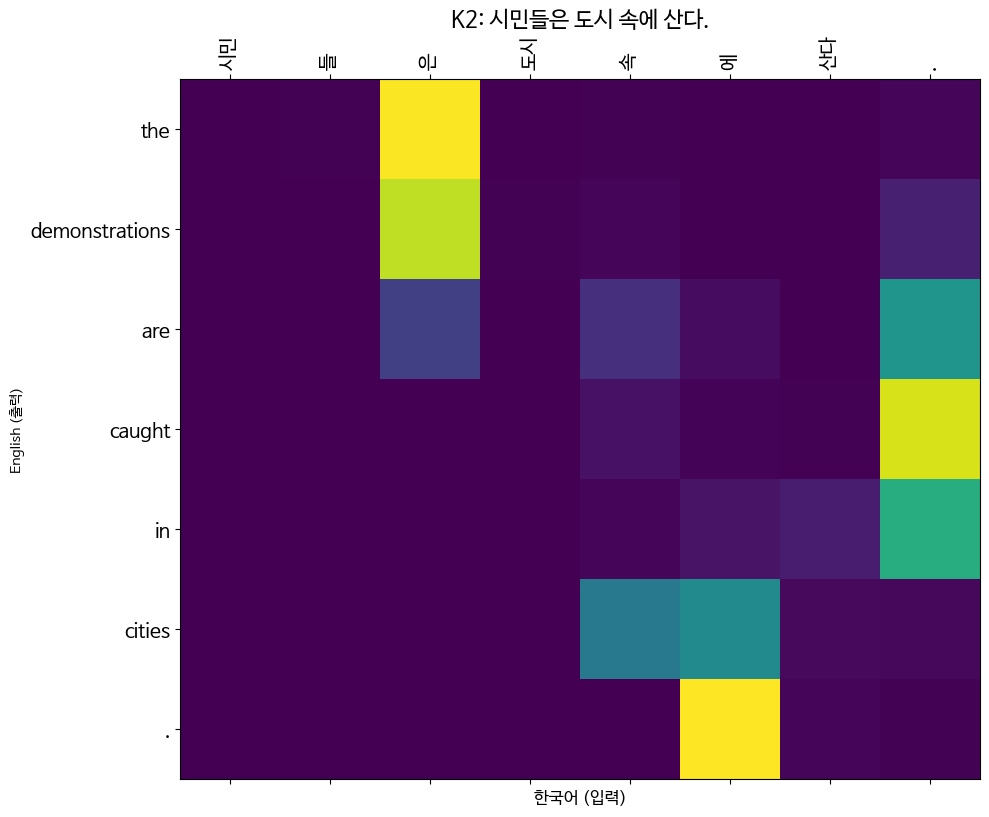


[K3] 입력: 커피는 필요 없다.
      번역: it s not only compatible with you .


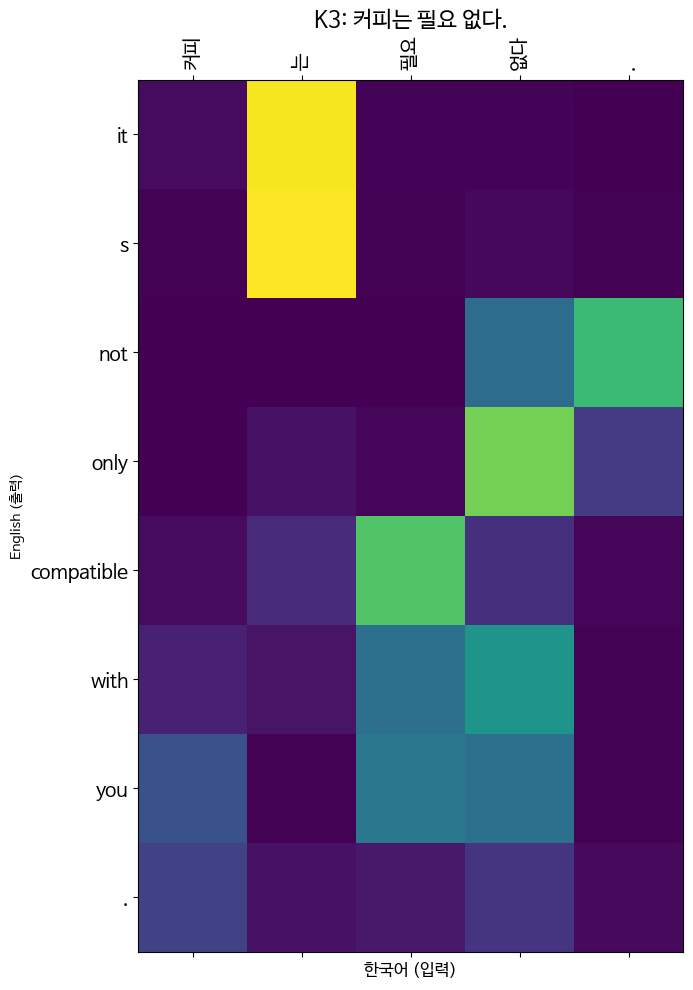


[K4] 입력: 일곱 명의 사망자가 발생했다.
      번역: seven civilian deaths were killed .


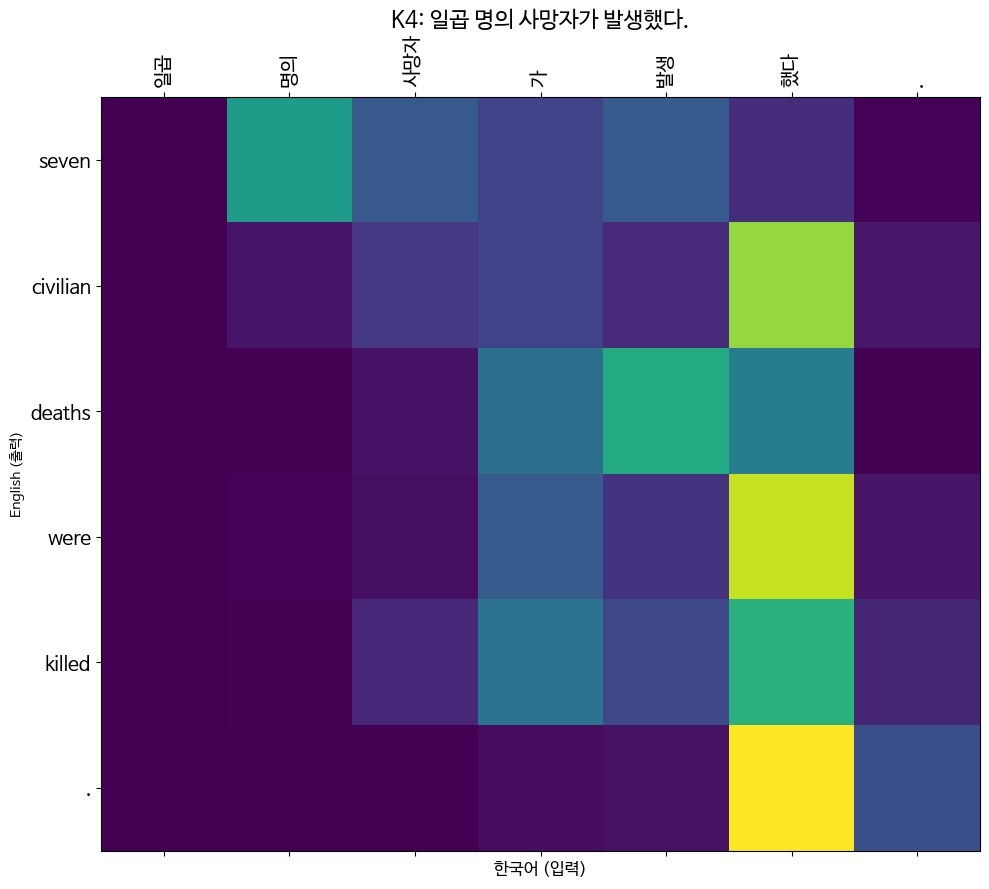

In [71]:
# ============================================================
# K1~K4 예문 모두에 대한 Attention Map 출력
# ============================================================

for tag, sent in submission_examples:
    translate_and_plot(sent, tag, model, kor_tokenizer, eng_tokenizer)
    print()

# 프로젝트 회고

이번 프로젝트를 통해 전처리의 중요성, Attention과 Teacher Forcing의 한계, 토크나이저 분리의 필요성을 직접 이해했고, Seq2Seq + Attention을 구현하며 NLP 모델 발전 흐름을 코드로 경험할 수 있었다
